In [1]:
# STEP 1: Install KaggleHub
!pip install -q kagglehub

# STEP 2: Import Libraries
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# STEP 3: Download MNIST Dataset from KaggleHub
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Dataset Path:", path)

# STEP 4: Check Dataset Files
print("\nFiles in Dataset Folder:")
print(os.listdir(path))

100%|██████████| 22.0M/22.0M [00:00<00:00, 76.8MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1

Files in Dataset Folder:
['train-labels-idx1-ubyte', 't10k-images.idx3-ubyte', 't10k-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 'train-images.idx3-ubyte', 't10k-labels.idx1-ubyte', 'train-labels.idx1-ubyte', 'train-images-idx3-ubyte']


In [2]:
# STEP 5: Load MNIST Dataset

# TensorFlow already provides MNIST directly
# We use it because it is clean and easy

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


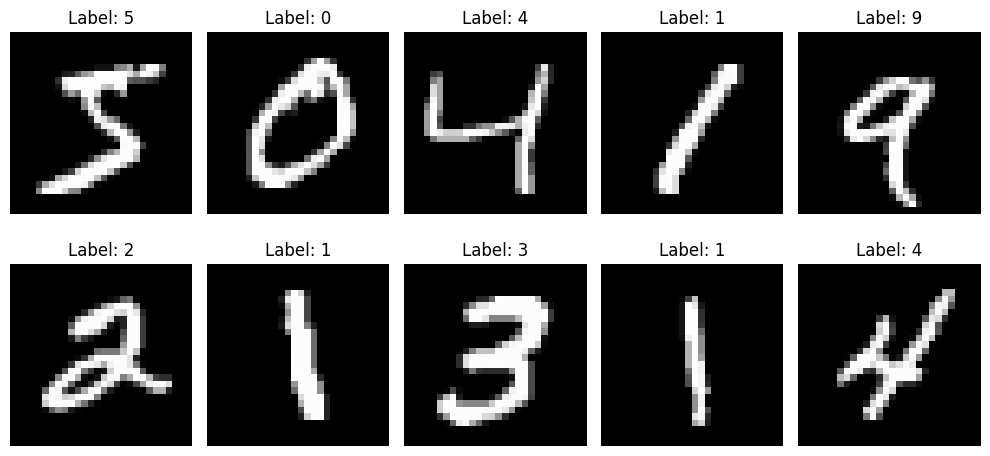

In [3]:
# STEP 6: Display Sample Images

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# STEP 7: Normalize Data

x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# STEP 8: Convert Labels to One-Hot Encoding

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("One Hot Encoded Label Example:")
print(y_train[0])

One Hot Encoded Label Example:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [6]:
# STEP 9: Build Neural Network Model

model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# STEP 10: Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# STEP 11: Train Model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9121 - loss: 0.2952 - val_accuracy: 0.9700 - val_loss: 0.1044
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9567 - loss: 0.1418 - val_accuracy: 0.9748 - val_loss: 0.0850
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9666 - loss: 0.1082 - val_accuracy: 0.9767 - val_loss: 0.0805
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9721 - loss: 0.0894 - val_accuracy: 0.9783 - val_loss: 0.0786
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9748 - loss: 0.0790 - val_accuracy: 0.9805 - val_loss: 0.0705
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9779 - loss: 0.0701 - val_accuracy: 0.9815 - val_loss: 0.0722
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9791 - loss: 0.0646 - val_accuracy: 0.9803 - val_loss: 0.0735
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9811 - loss: 0.0567 - 

In [9]:
# STEP 12: Evaluate Model

loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss     :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0807

Test Loss     : 0.08070476353168488
Test Accuracy : 0.9768999814987183


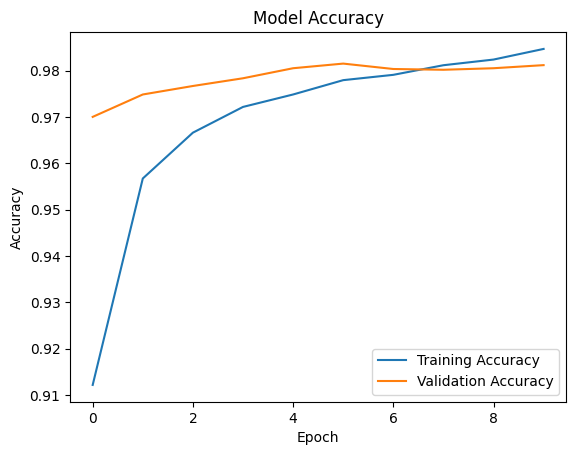

In [10]:
# STEP 13: Plot Accuracy Graph

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()
plt.show()

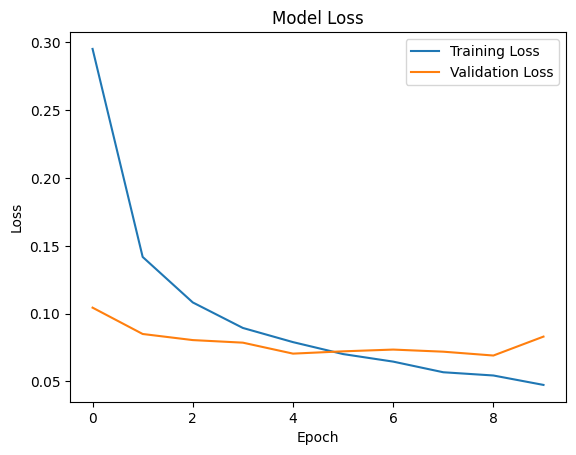

In [11]:
# STEP 14: Plot Loss Graph

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")

plt.legend()
plt.show()

In [12]:
# STEP 15: Predict on Test Images

predictions = model.predict(x_test)

# Convert probabilities to digit
predicted_labels = np.argmax(predictions, axis=1)

# Convert one-hot test labels back
true_labels = np.argmax(y_test, axis=1)

print("Predicted Digit :", predicted_labels[0])
print("Actual Digit    :", true_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Digit : 7
Actual Digit    : 7


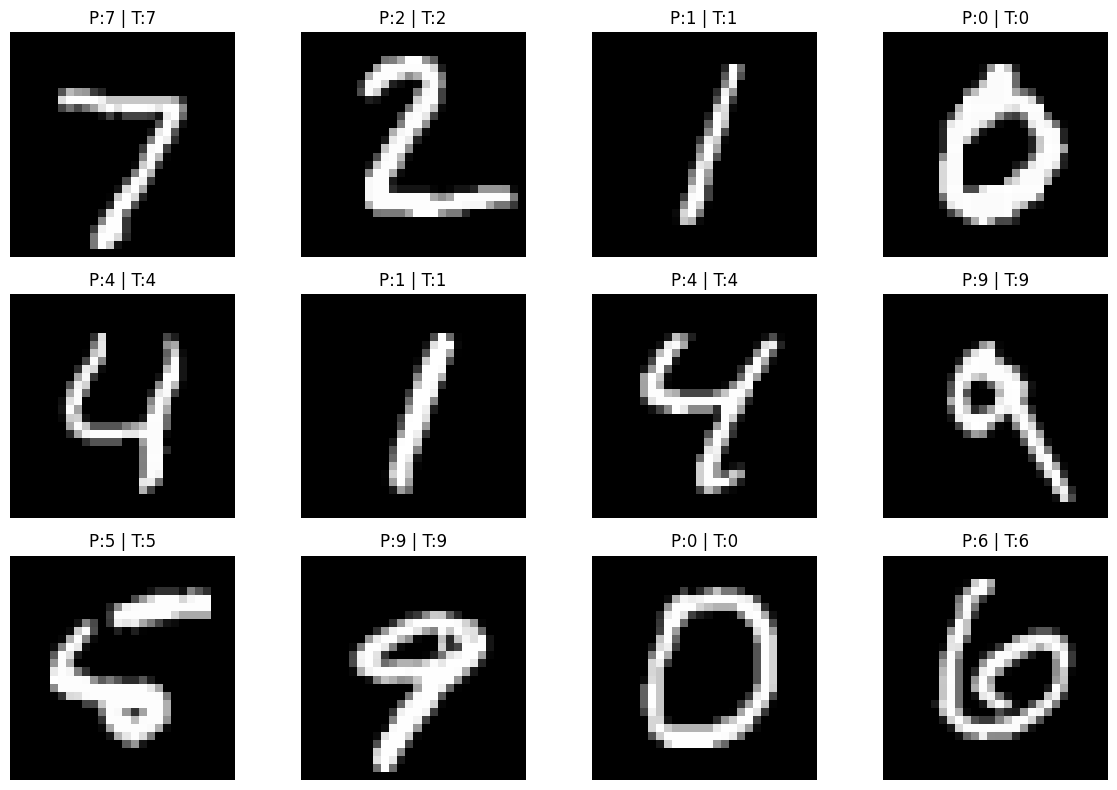

In [13]:
# STEP 16: Show Predictions

plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(x_test[i], cmap='gray')

    plt.title(f"P:{predicted_labels[i]} | T:{true_labels[i]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
# STEP 17: Save Model

model.save("mnist_digit_classifier.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
# STEP 18: Load Saved Model

from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_digit_classifier.h5")

print("Model Loaded Successfully")

Model Loaded Successfully
